# Editing images - Fast

A typical usage of "kernels" is to edit images. In this example, we will see how to use the `KernelAbstractions` library to edit images in a fast and efficient way.


#### Content
- [Introduction](#introduction)
- [Simple image kernel usage](#simple-image-kernels)
- [Large scale editing - comparison with CPU](#large-scale-editing---comparison-with-cpu)


### Introduction
For one that is not familiar with the usage of kernels for image editing, the idea is to apply a function (the kernel) to each pixel of the image, taking into account its neighbors. This is often used for tasks such as blurring, sharpening, edge detection, etc.

For example, if we want to apply a simple blur to an image, we can use a kernel that takes the average of the pixel and its neighbors. This can be done using a $3\times3$ kernel like this:

$$
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1 \\
\end{bmatrix}
$$

Similarly, for edge detection, we can use a kernel like this:
$$
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0 \\
\end{bmatrix}
$$
The idea with the last one is that it will highlight the edges of the image by taking the difference between the pixel and its neighbors. If the pixel is similar to its neighbors, the result will be close to zero, but if it is different, the result will be larger.

For more examples of kernels for image editing, one can check out the [Wikipedia page](https://en.wikipedia.org/wiki/Kernel_(image_processing)) or the [Victor Powell's interactive page](https://setosa.io/ev/image-kernels/).

### Simple image kernels 

We'll first start with a simple example of applying a blur kernel, and a "sharpen" kernel to an image. We will use the `KernelAbstractions` library to do this in a fast and efficient way.

In [2]:
using KernelAbstractions, CUDA
using Images, FileIO

backend = CUDABackend() # Specify backend

CUDABackend(false, false)

In [3]:
# Define helper functions to help translate images to tensors, and back.
function img_to_tensor(img)
    img_rgb = RGB.(img)
    tensor = channelview(img_rgb)
    return Float32.(tensor)
end

function tensor_to_img(tensor)
    @assert size(tensor, 1) == 3 "Tensor must have 3 channels"
    img = colorview(RGB, tensor)
    return img
end

tensor_to_img (generic function with 1 method)

Time to define some kernels!

In [35]:
@kernel function blur_kernel!(output::AbstractArray, input::AbstractArray)
    k, i, j = @index(Global, NTuple)
    C, H, W = size(input)
    if (1 <=k <=C) && (2 <= i <= H-1) && (2 <= j <= W-1)
        output[k, i, j] = (1/9) * (
            input[k,i,j] + 
            input[k,i-1,j] + 
            input[k,i,j-1] +
            input[k,i+1,j] +
            input[k,i,j+1] + 
            input[k,i+1,j+1] + 
            input[k,i-1,j+1] + 
            input[k,i-1,j-1] + 
            input[k,i+1,j-1]
            )
    elseif (1 <=k <=C) && (1 <= i <= H) && (1 <= j <= W) #Edges
        output[k,i,j] = input[k,i,j]
    end
end

@kernel function edge_detection_kernel!(output::AbstractArray, input::AbstractArray)
    k, i, j = @index(Global, NTuple)
    C, H, W = size(input)
    if (1 <=k <=C) && (2 <= i <= H-1) && (2 <= j <= W-1)
        output[k, i, j] = 5*input[k,i,j]
        - input[k,i-1,j]
        - input[k,i,j-1]
        - input[k,i+1,j]
        - input[k,i,j+1]
    elseif (1 <=k <=C) && (1 <= i <= H) && (1 <= j <= W) #Edges
        output[k,i,j] = input[k,i,j]
    end
end



function sharpenImage!(output, img) 
    backend = KernelAbstractions.get_backend(img)
    kernel! = sharpening_kernel!(backend)
    kernel!(output, img, ndrange=size(img))
    KernelAbstractions.synchronize(backend)
    return output
end

sharpenImage! (generic function with 1 method)

As has to be done with kernels, we have to define a "wrapper" function that will take care of the boundaries of the image, and specify the backend. 

In [36]:
function blurImage!(output, img) 
    backend = KernelAbstractions.get_backend(img)
    kernel! = blur_kernel!(backend)
    kernel!(output, img, ndrange=size(img))
    KernelAbstractions.synchronize(backend)
    return output
end

function edgeDetectImage!(output, img) 
    backend = KernelAbstractions.get_backend(img)
    kernel! = edge_detection_kernel!(backend)
    kernel!(output, img, ndrange=size(img))
    KernelAbstractions.synchronize(backend)
    return output
end

edgeDetectImage! (generic function with 1 method)

Moreover, let's also define some versions of these functions that will copy the image (Note the lack of exclamation mark). While we are at it we can also define functions that operate directly on the `Images` file, and not the array (#heart multiple dispatch!).

In [37]:
function blurImage(img::Array{Float32, 3})
    output = similar(img)
    imgC = deepcopy(img)
    blurImage!(output,imgC)
    return output
end

function edgeDetectImage(img::Array{Float32, 3})
    output = similar(img)
    imgC = deepcopy(img)
    edgeDetectImage!(output,imgC)
    return output
end

function blurImage(img::Matrix{RGB{N0f8}})
    img_tensor = img_to_tensor(img)
    output = similar(img_tensor)
    blurImage!(output,img_tensor)
    return tensor_to_img(output)
end

function edgeDetectImage(img::Matrix{RGB{N0f8}})
    img_tensor = img_to_tensor(img)
    output = similar(img_tensor)
    edgeDetectImage!(output,img_tensor)
    return tensor_to_img(output)
end


edgeDetectImage (generic function with 2 methods)

Now that we have all this boilerplate out of the way, we can apply our kernels to an image and see the results!

Check out this nice image of Phillip (credit to C. Wittens)

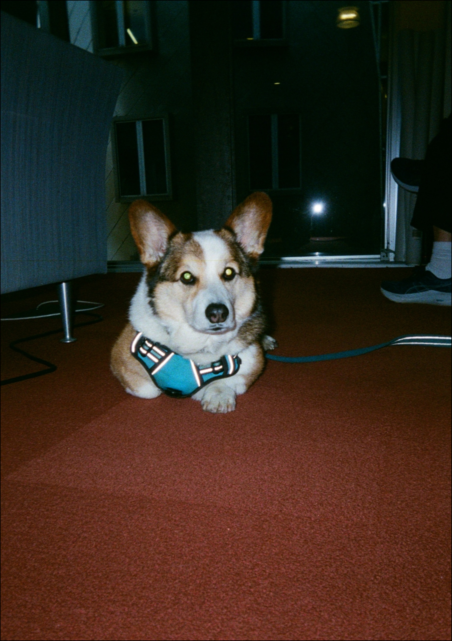

In [38]:
# Load Image
original_phil = load("PhilC.JPG")


Now look at the blurred version

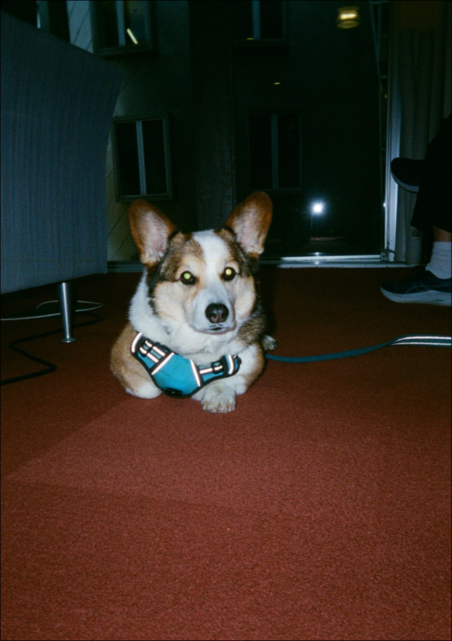

In [39]:
blurred_phil = blurImage(original_phil)

Cool! 

What about the edge detection?

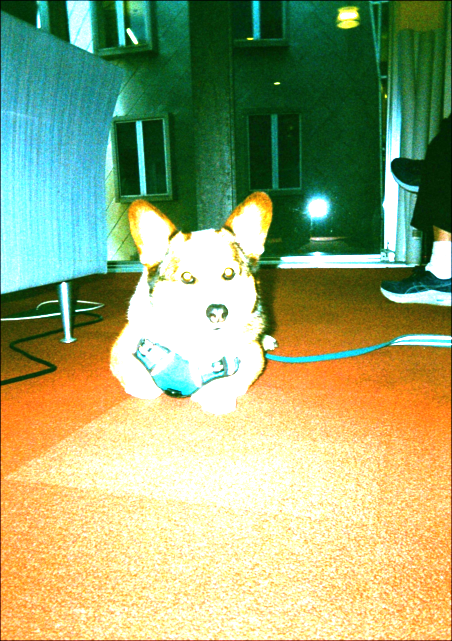

In [40]:
phils_edges = edgeDetectImage(original_phil)

### Large scale editing - comparison with CPU
Of course, the above example is not very impressive, since the image is small and the kernels are simple. However, the real power of using kernels for image editing comes when we have many - or large - images.

In [16]:
using BenchmarkTools, MLDatasets

In [ ]:
d = CIFAR10()



7-Zip (a) 25.01 (x64) : Copyright (c) 1999-2025 Igor Pavlov : 2025-08-03
 64-bit locale=en_US.UTF-8 Threads:128 OPEN_MAX:1048576, ASM


Extracting archive: 
--
Path = 
Type = tar
Code Page = UTF-8
Characteristics = ASCII

Everything is Ok

Folders: 1
Files: 8
Size:       184380149
Compressed: 9216


dataset CIFAR10:
  metadata  =>    Dict{String, Any} with 2 entries
  split     =>    :train
  features  =>    32×32×3×50000 Array{Float32, 4}
  targets   =>    50000-element Vector{Int64}

In [42]:
convert2image(d, 1:2) 

32×32×2 reinterpret(reshape, RGB{Float32}, ::Array{Float32, 4}) with eltype RGB{Float32}:
[:, :, 1] =
 RGB(0.231373, 0.243137, 0.247059)     …  RGB(0.580392, 0.486275, 0.403922)
 RGB(0.0627451, 0.0784314, 0.0784314)     RGB(0.478431, 0.341176, 0.223529)
 RGB(0.0980392, 0.0941176, 0.0823529)     RGB(0.427451, 0.286275, 0.164706)
 RGB(0.129412, 0.0980392, 0.0666667)      RGB(0.368627, 0.243137, 0.137255)
 RGB(0.196078, 0.12549, 0.0823529)        RGB(0.262745, 0.164706, 0.0980392)
 RGB(0.278431, 0.188235, 0.113725)     …  RGB(0.12549, 0.0509804, 0.0156863)
 RGB(0.380392, 0.270588, 0.156863)        RGB(0.258824, 0.184314, 0.117647)
 RGB(0.45098, 0.321569, 0.192157)         RGB(0.4, 0.290196, 0.180392)
 RGB(0.537255, 0.392157, 0.266667)        RGB(0.52549, 0.372549, 0.219608)
 RGB(0.603922, 0.470588, 0.34902)         RGB(0.521569, 0.360784, 0.215686)
 ⋮                                     ⋱  
 RGB(0.560784, 0.403922, 0.282353)        RGB(0.745098, 0.682353, 0.388235)
 RGB(0.584314, 0.419608